In [1]:
import numpy as np
import open3d as o3d
import os 


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [51]:
#import view 1 pointcloud
pcl0 = o3d.io.read_point_cloud(r'C:\Users\julia\Documents\Strawberry_Estimation\git_FS\Forschsem\juliatestet\cloud_aligned0.ply')
pcl1 = o3d.io.read_point_cloud(r'C:\Users\julia\Documents\Strawberry_Estimation\git_FS\Forschsem\juliatestet\cloud_aligned1.ply')
pcl2 = o3d.io.read_point_cloud(r'C:\Users\julia\Documents\Strawberry_Estimation\git_FS\Forschsem\juliatestet\cloud_aligned2.ply')

#o3d.visualization.draw_geometries([pcl1])

In [52]:
def trans_points(pcl, M):
    points = np.array(pcl.points)
    points = points[:,[0,1,2]]
    ones = np.ones((points.shape[0], 1))
    points_homogeneous = np.hstack((points, ones))
    trans_points = points_homogeneous @ M
    trans_points = trans_points[:,[0,1,2]]
    trans_points_3d = trans_points[:,:3]
    pcl.points = o3d.utility.Vector3dVector(trans_points_3d)

    return pcl 

In [53]:
# pos1 camera
x1=148.567*10**-3
y1=0.000*10**-3
z1=283.586*10**-3

rx1 = -180
ry1 = 90
rz1 = 0

# pos0 camera 
x0 = 188.205*10**-3
y0 = 58.384*10**-3
z0 = 249.002*10**-3

rx0 = 63.286
ry0 = 55.563
rz0 = 127.337

# pos2 camera
x2 = 195.183*10**-3
y2 = -34.680*10**-3
z2 = 243.936*10**-3

rx2 = -71.161
ry2 = 50.263
rz2 = -104.430

def get_rotation_matrix(i):
    if i == 0:
        x = x0
        y = y0
        z = z0
        rx = rx0
        ry = ry0
        rz = rz0
    elif i == 1:
        x = x1
        y = y1
        z = z1
        rx = rx1
        ry = ry1
        rz = rz1
    else:
        x = x2
        y = y2
        z = z2
        rx = rx2
        ry = ry2
        rz = rz2

    Rx = np.array([[1, 0, 0],
                [0, np.cos(np.radians(rx)), -np.sin(np.radians(rx))],
                [0, np.sin(np.radians(rx)), np.cos(np.radians(rx))]])

    Ry = np.array([[np.cos(np.radians(ry)), 0, np.sin(np.radians(ry))],
                [0, 1, 0],
                [-np.sin(np.radians(ry)), 0, np.cos(np.radians(ry))]])

    Rz = np.array([[np.cos(np.radians(rz)), -np.sin(np.radians(rz)), 0],
                [np.sin(np.radians(rz)), np.cos(np.radians(rz)), 0],
                [0, 0, 1]])

    R = Rx @ Ry @ Rz

    t = np.array([x,y,z,])

    M = np.hstack((R, t.reshape(3,1)))

    M = np.vstack((M, np.array([0,0,0,1])))
    return M

S_CAM_TO_TCP = np.array([
    [ 0.0, -1.0,  0.0],   # x_r = -y_c
    [ 1.0,  0.0,  0.0],   # y_r =  x_c
    [ 0.0,  0.0,  1.0],   # z_r =  z_c
], dtype=float)

for i in [0,1,2]:
    if i == 0:
        pcl = pcl0
    elif i == 1:
        pcl = pcl1
    else:
        pcl = pcl2

    M = get_rotation_matrix(i)

    points = np.array(pcl.points)*9.999999747378752e-05
    #swap axes x y
    points = points @ S_CAM_TO_TCP

    # convert to homogeneous coordinates
    ones = np.ones((points.shape[0], 1))
    points_homogeneous = np.hstack((points, ones))
    trans_points = points_homogeneous @ M
    print(trans_points.shape)

    # convert back to 3D coordinates
    trans_points_3d = trans_points[:,:3]
    pcl.points = o3d.utility.Vector3dVector(trans_points_3d)
    o3d.io.write_point_cloud(f'view{i}.ply', pcl, format='ply')











# # translation matrix (homogeneous)

# T = np.array([[1, 0, 0 , x], 
#               [0, 1, 0 , y], 
#               [0, 0, 1 , z], 
#               [0, 0, 0 , 1]])

# T_inv = np.array([[1, 0, 0 , -x], 
#                   [0, 1, 0 , -y], 
#                   [0, 0, 1 , -z], 
#                   [0, 0, 0 , 1]])


#Rotation Matrix for rx and ry homo

# R = np.array([[0,0,1,0],
#               [0,-1,0,0],
#               [1,0,0,0],
#               [0,0,0,1]])

# Combine rotation and translation into a homogeneous transformation matrix

# M = np.hstack((R, t.reshape(3,1)))

# M = np.vstack((M, np.array([0,0,0,1])))

# test = [0,0,0,1]

#trans_test= M @ test

print(M)

(27276, 4)
(16617, 4)
(32037, 4)
[[-0.15930281  0.61909754  0.7689869   0.195183  ]
 [-0.13135949 -0.78530043  0.60501894 -0.03468   ]
 [ 0.97845148 -0.00463251  0.2064249   0.243936  ]
 [ 0.          0.          0.          1.        ]]


In [54]:
rot1 = o3d.io.read_point_cloud(r'C:\Users\julia\Documents\Strawberry_Estimation\git_FS\Forschsem\juliatestet\view0.ply')
rot2 = o3d.io.read_point_cloud(r'C:\Users\julia\Documents\Strawberry_Estimation\git_FS\Forschsem\juliatestet\view1.ply')
rot3 = o3d.io.read_point_cloud(r'C:\Users\julia\Documents\Strawberry_Estimation\git_FS\Forschsem\juliatestet\view2.ply')

o3d.visualization.draw_geometries([rot1,rot2, rot3])# 

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: Das Handle ist ungültig. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: Der angeforderte Transformationsvorgang wird nicht unterstützt. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: Der angeforderte Transformationsvorgang wird nicht unterstützt. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: Der angeforderte Transformationsvorgang wird nicht unterstützt. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: Der angeforderte Transformationsvorgang wird nicht unterstützt. 


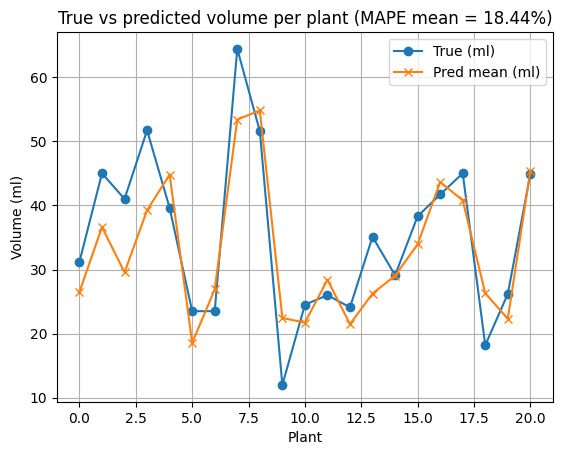

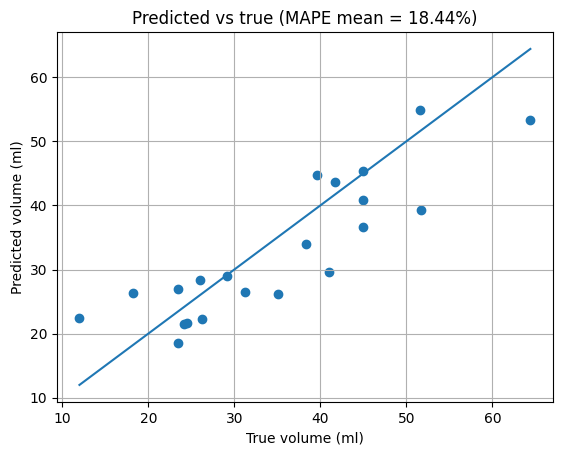

(18.442406006328675, 15.652271071333992)

In [2]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


calc_text = """
id,calculated_volumen
plant_000_cloud_0,3.019200094100716e-05
plant_000_cloud_1,2.9118476331760583e-05
plant_000_cloud_2,2.016817144389164e-05
plant_001_cloud_0,3.906598092350571e-05
plant_001_cloud_1,5.5695360442930434e-05
plant_001_cloud_2,1.5073779722407078e-05
plant_002_cloud_0,3.538236377452522e-05
plant_002_cloud_1,2.9688694214078534e-05
plant_002_cloud_2,2.3616002937433092e-05
plant_003_cloud_0,3.937483807128241e-05
plant_003_cloud_1,4.701664665271959e-05
plant_003_cloud_2,3.132899636676258e-05
plant_004_cloud_0,5.390434463283209e-05
plant_004_cloud_1,6.785138489095458e-05
plant_004_cloud_2,1.2649794038975888e-05
plant_005_cloud_0,1.9706246148429887e-05
plant_005_cloud_1,2.1106383642051728e-05
plant_005_cloud_2,1.4835149991472448e-05
plant_006_cloud_0,3.046610304778492e-05
plant_006_cloud_1,2.7067253911403418e-05
plant_006_cloud_2,2.3155391868290266e-05
plant_007_cloud_0,2.0482799297994435e-05
plant_007_cloud_1,6.712679773207996e-05
plant_007_cloud_2,7.253297489161966e-05
plant_008_cloud_0,4.484793132629158e-05
plant_008_cloud_1,6.095941572834067e-05
plant_008_cloud_2,5.8592777209654556e-05
plant_009_cloud_0,4.578490274280782e-05
plant_009_cloud_1,1.2941048163307435e-05
plant_009_cloud_2,8.585796685083345e-06
plant_010_cloud_0,8.878098510689766e-06
plant_010_cloud_1,3.705884102405732e-05
plant_010_cloud_2,1.9225781759599502e-05
plant_011_cloud_0,1.5602675128327806e-05
plant_011_cloud_1,2.6763206736222747e-05
plant_011_cloud_2,4.2817912145773444e-05
plant_012_cloud_0,2.3309452648795738e-05
plant_012_cloud_1,1.9870215356096462e-05
plant_012_cloud_2,2.1264479619818784e-05
plant_013_cloud_0,2.051597850788279e-05
plant_013_cloud_1,3.4974920910120345e-05
plant_013_cloud_2,2.3257218546565842e-05
plant_014_cloud_1,2.0220724874711887e-05
plant_014_cloud_2,3.787172187223302e-05
plant_015_cloud_0,2.3126802040609374e-05
plant_015_cloud_1,4.354893232217381e-05
plant_015_cloud_2,3.511357656716556e-05
plant_016_cloud_1,4.1272983973356794e-05
plant_016_cloud_2,4.603281922993252e-05
plant_017_cloud_1,4.293890840484862e-05
plant_017_cloud_2,3.8635162166450893e-05
plant_018_cloud_1,1.9636439128187338e-05
plant_018_cloud_2,3.294003059391408e-05
plant_019_cloud_0,2.1107275921038496e-05
plant_019_cloud_1,2.596005782545857e-05
plant_019_cloud_2,1.990135935274621e-05
plant_020_cloud_0,3.488673655173105e-05
plant_020_cloud_1,4.84652143149993e-05
plant_020_cloud_2,5.2840243518828335e-05
""".strip()

gt_pairs = [
    (0,"31,2"), (1,"45"), (2,"41"), (3,"51,7"), (4,"39,6"), (5,"23,5"),
    (6,"23,5"), (7,"64,4"), (8,"51,6"), (9,"12"), (10,"24,5"), (11,"26"),
    (12,"24,1"), (13,"35,1"), (14,"29,1"), (15,"38,3"), (16,"41,7"),
    (17,"45"), (18,"18,2"), (19,"26,2"), (20,"44,9"),
]
gt = {i: float(s.replace(",", ".")) for i, s in gt_pairs}

rows = []
for line in calc_text.splitlines():
    _id, val = line.split(",")
    m = re.match(r"plant_(\d+)_cloud_(\d+)", _id.strip())
    if not m:
        continue
    rows.append((int(m.group(1)), int(m.group(2)), float(val), _id.strip()))

df = pd.DataFrame(rows, columns=["plant", "cloud", "vol_m3", "id"])

agg = (
    df.groupby("plant")
      .agg(vol_m3_mean=("vol_m3", "mean"),
           vol_m3_median=("vol_m3", "median"),
           n_clouds=("vol_m3", "size"))
      .reset_index()
      .sort_values("plant")
      .reset_index(drop=True)
)

M3_TO_ML = 1e6
agg["pred_ml_mean"] = agg["vol_m3_mean"] * M3_TO_ML
agg["pred_ml_median"] = agg["vol_m3_median"] * M3_TO_ML
agg["true_ml"] = agg["plant"].map(gt)

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100.0)

mape_mean = mape(agg["true_ml"], agg["pred_ml_mean"])
mape_median = mape(agg["true_ml"], agg["pred_ml_median"])

agg["APE_mean_%"] = np.abs((agg["true_ml"] - agg["pred_ml_mean"]) / agg["true_ml"]) * 100.0
agg["APE_median_%"] = np.abs((agg["true_ml"] - agg["pred_ml_median"]) / agg["true_ml"]) * 100.0


plt.figure()
plt.plot(agg["plant"], agg["true_ml"], marker="o", label="True (ml)")
plt.plot(agg["plant"], agg["pred_ml_mean"], marker="x", label="Pred mean (ml)")
plt.xlabel("Plant")
plt.ylabel("Volume (ml)")
plt.title(f"True vs predicted volume per plant (MAPE mean = {mape_mean:.2f}%)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.scatter(agg["true_ml"], agg["pred_ml_mean"])
mn = float(min(agg["true_ml"].min(), agg["pred_ml_mean"].min()))
mx = float(max(agg["true_ml"].max(), agg["pred_ml_mean"].max()))
plt.plot([mn, mx], [mn, mx])
plt.xlabel("True volume (ml)")
plt.ylabel("Predicted volume (ml)")
plt.title(f"Predicted vs true (MAPE mean = {mape_mean:.2f}%)")
plt.grid(True)
plt.show()

mape_mean, mape_median


In [ ]:
# translate pointcloud in robo coordinate system
points = np.array(pcl1.points)*9.999999747378752e-05
#swap axes x y
points = points[:, [1, 0, 2]]

# convert to homogeneous coordinates
ones = np.ones((points.shape[0], 1))
points_homogeneous = np.hstack((points, ones))

print(points_homogeneous.shape)

(135292, 4)


In [ ]:


# translate pointcloud
trans_points = points_homogeneous @ M
print(trans_points.shape)
# convert back to 3D coordinates
trans_points = trans_points[:,[1,0,2]]
trans_points_3d = trans_points[:,:3]
pcl1.points = o3d.utility.Vector3dVector(trans_points_3d)
o3d.visualization.draw_geometries([pcl1])
#o3d.io.write_point_cloud('view1.ply', pcl1, format='ply')




(135292, 4)


True

In [ ]:
# view 0 same stuff but with rotation
pcl0 = o3d.io.read_point_cloud(r'C:\Users\julia\Documents\Strawberry_Estimation\git_FS\Forschsem\Datensatz\Aufnahme003\cloud_raw0.ply')


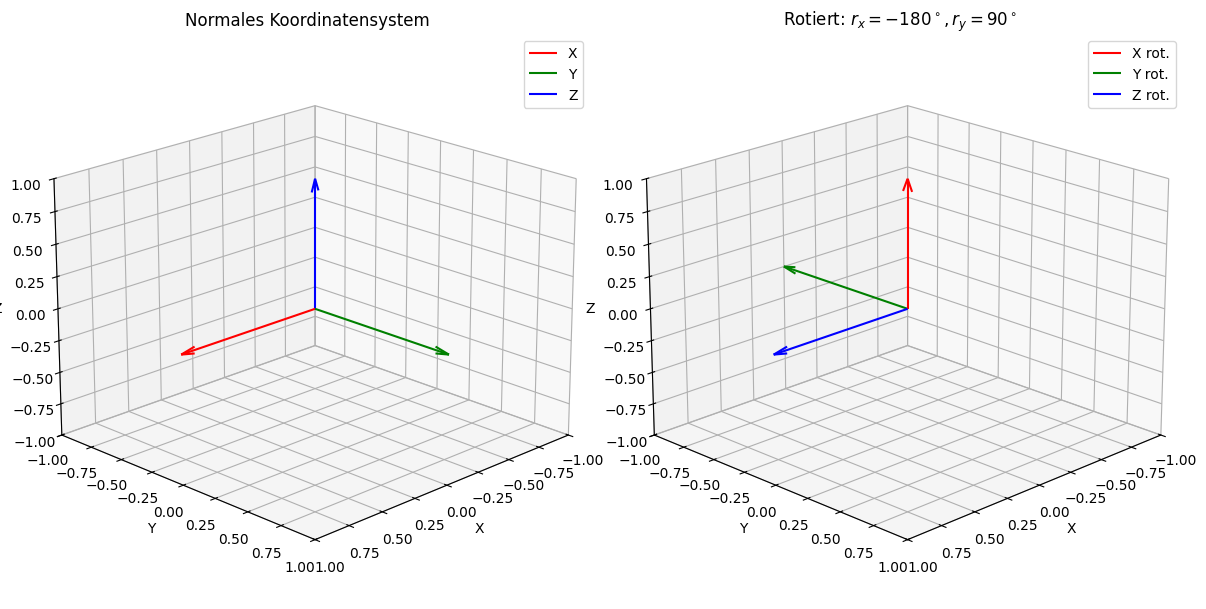

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def create_plot():
    fig = plt.figure(figsize=(12, 6))

    # --- Hilfsfunktion für Rotationsmatrizen ---
    def get_rotation_matrix(rx_deg, ry_deg):
        ax = np.radians(rx_deg)
        ay = np.radians(ry_deg)
        
        # Rotation um X
        Rx = np.array([
            [1, 0, 0],
            [0, np.cos(ax), -np.sin(ax)],
            [0, np.sin(ax), np.cos(ax)]
        ])
        
        # Rotation um Y
        Ry = np.array([
            [np.cos(ay), 0, np.sin(ay)],
            [0, 1, 0],
            [-np.sin(ay), 0, np.cos(ay)]
        ])
        
        return Rx @ Ry  # Erst X, dann Y Drehung

    # Ursprung und Standard-Achsen (Einhalsvektoren)
    origin = np.array([0, 0, 0])
    basis = np.eye(3) # [[1,0,0], [0,1,0], [0,0,1]]
    colors = ['r', 'g', 'b'] # X=Rot, Y=Grün, Z=Blau
    labels = ['X', 'Y', 'Z']

    # --- Plot 1: Normales System ---
    ax1 = fig.add_subplot(121, projection='3d')
    for i in range(3):
        ax1.quiver(*origin, *basis[:, i], color=colors[i], label=labels[i], arrow_length_ratio=0.1)
    
    ax1.set_title("Normales Koordinatensystem")
    ax1.set_xlim([-1, 1]); ax1.set_ylim([-1, 1]); ax1.set_zlim([-1, 1])
    ax1.legend()

    # --- Plot 2: Rotiertes System (rx=-180, ry=90) ---
    ax2 = fig.add_subplot(122, projection='3d')
    R = get_rotation_matrix(-180, 90)
    rotated_basis = R @ basis

    for i in range(3):
        ax2.quiver(*origin, *rotated_basis[:, i], color=colors[i], label=f"{labels[i]} rot.", arrow_length_ratio=0.1)

    ax2.set_title("Rotiert: $r_x=-180^\circ, r_y=90^\circ$")
    ax2.set_xlim([-1, 1]); ax2.set_ylim([-1, 1]); ax2.set_zlim([-1, 1])
    ax2.legend()

    # Gleiche Ansicht für beide Plots einstellen
    for ax in [ax1, ax2]:
        ax.view_init(elev=20, azim=45)
        ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')

    plt.tight_layout()
    plt.show()

create_plot()

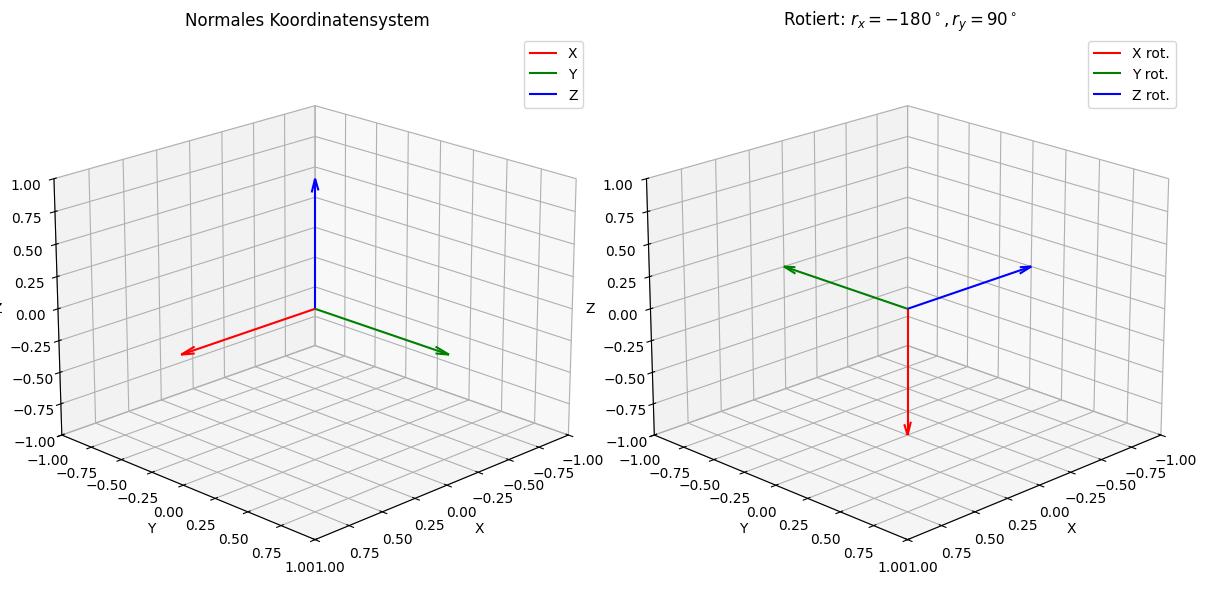

In [16]:
def create_plot():
    fig = plt.figure(figsize=(12, 6))

    # --- Hilfsfunktion für Rotationsmatrizen ---
    def get_rotation_matrix(rx_deg, ry_deg):
        ax = np.radians(rx_deg)
        ay = np.radians(ry_deg)
        
        # Rotation um X
        Rx = np.array([
            [1, 0, 0],
            [0, np.cos(ax), -np.sin(ax)],
            [0, np.sin(ax), np.cos(ax)]
        ])
        
        # Rotation um Y
        Ry = np.array([
            [np.cos(ay), 0, np.sin(ay)],
            [0, 1, 0],
            [-np.sin(ay), 0, np.cos(ay)]
        ])
        
        return Ry @ Rx  # Erst X, dann Y Drehung

    # Ursprung und Standard-Achsen (Einhalsvektoren)
    origin = np.array([0, 0, 0])
    basis = np.eye(3) # [[1,0,0], [0,1,0], [0,0,1]]
    colors = ['r', 'g', 'b'] # X=Rot, Y=Grün, Z=Blau
    labels = ['X', 'Y', 'Z']

    # --- Plot 1: Normales System ---
    ax1 = fig.add_subplot(121, projection='3d')
    for i in range(3):
        ax1.quiver(*origin, *basis[:, i], color=colors[i], label=labels[i], arrow_length_ratio=0.1)
    
    ax1.set_title("Normales Koordinatensystem")
    ax1.set_xlim([-1, 1]); ax1.set_ylim([-1, 1]); ax1.set_zlim([-1, 1])
    ax1.legend()

    # --- Plot 2: Rotiertes System (rx=-180, ry=90) ---
    ax2 = fig.add_subplot(122, projection='3d')
    R = get_rotation_matrix(180, 90)
    rotated_basis = R @ basis

    for i in range(3):
        ax2.quiver(*origin, *rotated_basis[:, i], color=colors[i], label=f"{labels[i]} rot.", arrow_length_ratio=0.1)

    ax2.set_title("Rotiert: $r_x=-180^\circ, r_y=90^\circ$")
    ax2.set_xlim([-1, 1]); ax2.set_ylim([-1, 1]); ax2.set_zlim([-1, 1])
    ax2.legend()

    # Gleiche Ansicht für beide Plots einstellen
    for ax in [ax1, ax2]:
        ax.view_init(elev=20, azim=45)
        ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')

    plt.tight_layout()
    plt.show()

create_plot()

c:\Users\julia\Documents\Strawberry_Estimation\.venv\lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


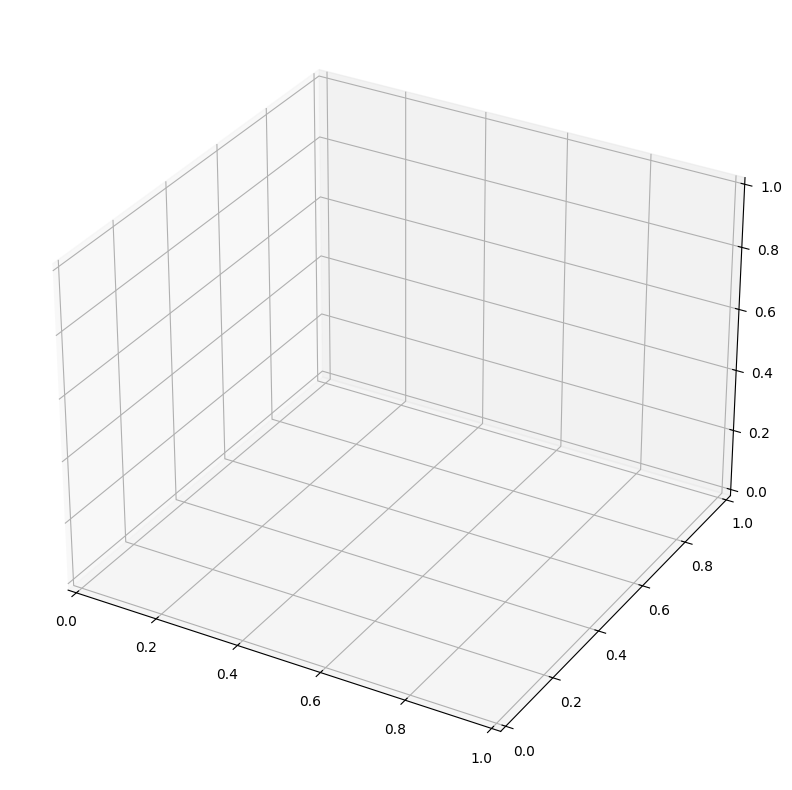

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation

def get_rotation_matrix(rx_deg, ry_deg):
    ax = np.radians(rx_deg)
    ay = np.radians(ry_deg)
    
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(ax), -np.sin(ax)],
        [0, np.sin(ax), np.cos(ax)]
    ])
    
    Ry = np.array([
        [np.cos(ay), 0, np.sin(ay)],
        [0, 1, 0],
        [-np.sin(ay), 0, np.cos(ay)]
    ])
    
    # Hier wichtig: Erst X, dann Y
    return Ry @ Rx

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

def update(frame):
    ax.cla()
    ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1]); ax.set_zlim([-1, 1])
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    
    # Sequentielle Logik
    if frame <= 100:
        # Phase 1: Nur X dreht sich
        curr_rx = -180 * (frame / 100)
        curr_ry = 0
        phase_text = f"Phase 1: Rotation um X ({curr_rx:.1f}°)"
    else:
        # Phase 2: X ist fertig, Y dreht sich
        curr_rx = -180
        curr_ry = 90 * ((frame - 100) / 100)
        phase_text = f"Phase 2: Rotation um Y ({curr_ry:.1f}°)"
    
    ax.set_title(phase_text)
    
    R = get_rotation_matrix(curr_rx, curr_ry)
    basis = np.eye(3)
    rotated_basis = R @ basis
    
    origin = [0, 0, 0]
    colors = ['r', 'g', 'b']
    labels = ['X', 'Y', 'Z']
    
    for i in range(3):
        ax.quiver(*origin, *rotated_basis[:, i], color=colors[i], 
                  label=labels[i], arrow_length_ratio=0.1, linewidth=2)
    
    ax.legend(loc='upper left')
    ax.view_init(elev=20, azim=45)

# 200 Frames für beide Phasen
ani = FuncAnimation(fig, update, frames=201, interval=30, repeat=True)

plt.tight_layout()
plt.show()